# SHYAM SUNDER
**LARGE LANGUAGE MODEL - IV sem**


>Reg : 2023LCSE07AED645  Class - CSE AIML C


> Mail : sshyamlebtech24@ced.alliance.edu.in

CLASS - 13/01/2026

1 . Fine Tunig **BERT** for **sentiment analysis**

In [ ]:
pip install transformers datasets torch evaluate accelerate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv("IMDB Dataset.csv", engine='python')
print(df.head())
print(df["sentiment"].value_counts())
df["label"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})


                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["review"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

model_name = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
from transformers import TrainingArguments
import evaluate
import numpy as np
from transformers import Trainer
train_encodings = tokenizer(
    train_texts,
    truncation=True,
    padding=True,
    max_length=256
)

test_encodings = tokenizer(
    test_texts,
    truncation=True,
    padding=True,
    max_length=256
)

training_args = TrainingArguments(
    output_dir="./bert-imdb-kaggle",
    evaluation_strategy="epoch",
    save_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_dir="./logs",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True
)

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics
)

trainer.train()



TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

CLASS - 20/01/2026

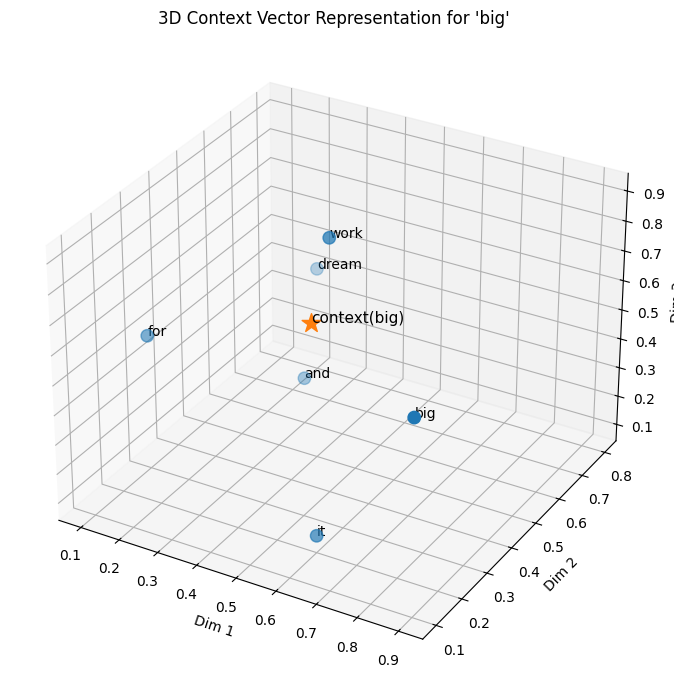

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

words = ["dream", "big", "and", "work", "for", "it"]

embeddings = tf.constant([
    [0.2, 0.8, 0.4],
    [0.9, 0.1, 0.7],
    [0.3, 0.6, 0.2],
    [0.5, 0.4, 0.9],
    [0.1, 0.3, 0.5],
    [0.6, 0.2, 0.1]
], dtype=tf.float32)

big_index = words.index("big")
context_indices = [0, 2]
context_vector = tf.reduce_mean(tf.gather(embeddings, context_indices), axis=0)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

x, y, z = embeddings.numpy().T
ax.scatter(x, y, z, s=80)

for i, word in enumerate(words):
    ax.text(x[i], y[i], z[i], word, fontsize=10)

ax.scatter(
    context_vector[0],
    context_vector[1],
    context_vector[2],
    s=200,
    marker="*"
)

ax.text(
    context_vector[0],
    context_vector[1],
    context_vector[2],
    "context(big)",
    fontsize=11
)

ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
ax.set_title("3D Context Vector Representation for 'big'")

plt.tight_layout()
plt.show()


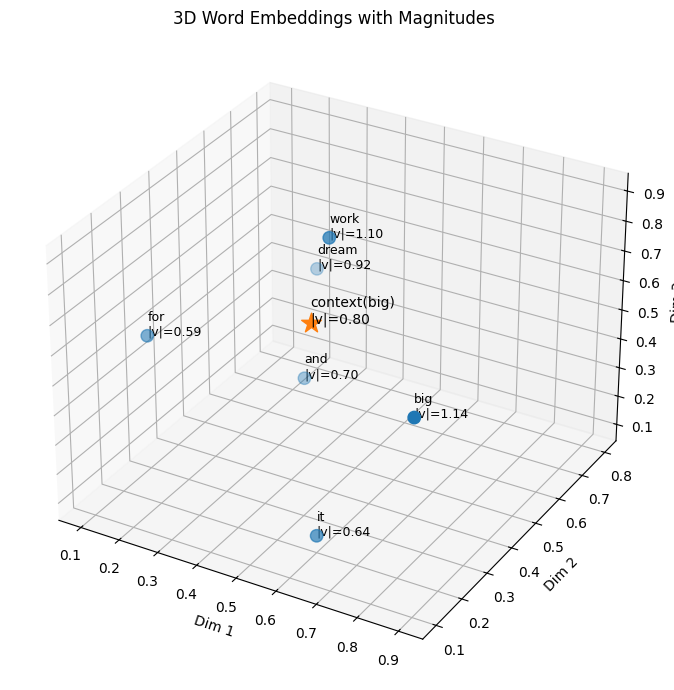

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D

words = ["dream", "big", "and", "work", "for", "it"]

embeddings = tf.constant([
    [0.2, 0.8, 0.4],
    [0.9, 0.1, 0.7],
    [0.3, 0.6, 0.2],
    [0.5, 0.4, 0.9],
    [0.1, 0.3, 0.5],
    [0.6, 0.2, 0.1]
], dtype=tf.float32)

big_index = words.index("big")
context_indices = [0, 2]
context_vector = tf.reduce_mean(tf.gather(embeddings, context_indices), axis=0)

magnitudes = tf.norm(embeddings, axis=1)
context_magnitude = tf.norm(context_vector)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

x, y, z = embeddings.numpy().T
ax.scatter(x, y, z, s=80)

for i, word in enumerate(words):
    ax.text(x[i], y[i], z[i], f"{word}\n|v|={magnitudes[i].numpy():.2f}", fontsize=9)

ax.scatter(
    context_vector[0],
    context_vector[1],
    context_vector[2],
    s=220,
    marker="*"
)

ax.text(
    context_vector[0],
    context_vector[1],
    context_vector[2],
    f"context(big)\n|v|={context_magnitude.numpy():.2f}",
    fontsize=10
)

ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
ax.set_title("3D Word Embeddings with Magnitudes")

plt.tight_layout()
plt.show()


**class : 21-01-2026**

***O'REILLY® Hands-On Large Language Models - Chapter 1 programs***

In [ ]:
 %%capture
!pip install transformers==4.41.2 accelerate==0.31.0

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load model and tokenizer
model = AutoModelForCausalLM.from_pretrained(
    "microsoft/Phi-3-mini-4k-instruct",
    device_map="cuda",
    torch_dtype="auto",
    trust_remote_code=False,
)
tokenizer = AutoTokenizer.from_pretrained("microsoft/Phi-3-mini-4k-instruct")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/967 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/306 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/599 [00:00<?, ?B/s]

In [ ]:
from transformers import pipeline

# Create a pipeline
generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    return_full_text=False,
    max_new_tokens=500,
    do_sample=False
)

Device set to use cuda
The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [ ]:
# The prompt (user input / query)
messages = [
    {"role": "user", "content": "how teacher feel if i bunk her class"}
]

# Generate output
output = generator(messages)
print(output[0]["generated_text"])

 As an AI, I don't have personal feelings, but I can tell you that teachers generally do not appreciate students skipping class. It can be frustrating for teachers because it disrupts the learning process for themselves and their peers. It also shows a lack of respect for the teacher's time and effort. If a student consistently skips class, it may lead to negative consequences such as lower grades, disciplinary action, or a strained relationship between the student and the teacher.


**22-01-2026** - ***tokenization and embeddings (2 ways of tokenization, 2 ways of embeddings (word2vec) compulsory Single head attention multi head attention***

***1A — Tokenization***



*A. WHITE SPACE*

In [ ]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

text = "Every moment is a beginning"
tokens = text.split()

encoder = OneHotEncoder(sparse_output=False)
vectors = encoder.fit_transform(np.array(tokens).reshape(-1, 1))

print("Tokens:", tokens)
print("Vectors:\n", vectors)

Tokens: ['Every', 'moment', 'is', 'a', 'beginning']
Vectors:
 [[1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]]


embedding

In [ ]:
!pip install gensim
from gensim.models import Word2Vec

text = "Every moment is a beginning"
tokens = text.split()

model = Word2Vec(
    sentences=[tokens],
    vector_size=100,
    window=5,
    min_count=1,
    workers=1,
    sg=1
)

for word in tokens:
    print(word)
    print(model.wv[word])
    print()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 92.0 MB/s eta 0:00:00
Every
[-0.00713902  0.00124103 -0.00717672 -0.00224462  0.0037193   0.00583312
  0.00119818  0.00210273 -0.00411039  0.00722533 -0.00630704  0.00464722
 -0.00821997  0.00203647 -0.00497705 -0.00424769 -0.00310898  0.00565521
  0.0057984  -0.00497465  0.00077333 -0.00849578  0.00780981  0.00925729
 -0.00274233  0.00080022  0.00074665  0.00547788 -0.00860608  0.00058446
  0.00686942  0.00223159  0.00112468 -0.00932216  0.00848237 -0.00626413
 -0.00299237  0.00349379 -0.00077263  0.00141129  0.00178199 -0.0068289
 -0.00972481  0.00904058  0.00619805 -0.00691293  0.00340348  0.00020606
  0.00475375 -0.00711994  0.00402695  0.00434743  0.00995737 -0.00447374
 -0.00138926 -0.00731732 -0.00969783 -0.00908026 -0.00102275 -0.00650329
  0.00484973 -0.00616403  0.00251919  0.00073944 -0.00339215 -0.00097922
  0.00997913  0.00914589 -0.00446183  0.00908303 -0.00564176  0.00593092
 -0.00309722  0.00343175  0.00301723  0.

*B. Character-Level*

In [ ]:
text = "dream big"
tokens = list(text.replace(" ", ""))
print(tokens)


['d', 'r', 'e', 'a', 'm', 'b', 'i', 'g']


*C. Subword NLP *

In [ ]:
from transformers import BertTokenizer

text = "Dreaming big and working hard leads to success"
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokens = tokenizer.tokenize(text)
print(tokens)


['dreaming', 'big', 'and', 'working', 'hard', 'leads', 'to', 'success']


*D. Subword Tokenization (NLP Library: BERT WordPiece)*

In [ ]:
from transformers import BertTokenizer

text = "Dreaming big and working hard leads to success"
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
tokens = tokenizer.tokenize(text)
print(tokens)


['dreaming', 'big', 'and', 'working', 'hard', 'leads', 'to', 'success']


*E. Stopword Removal (NLP Library: NLTK)*

In [ ]:
import nltk
from nltk.corpus import stopwords

nltk.download("stopwords")

text = "Dreaming big and working hard leads to success"
words = text.lower().split()
stops = set(stopwords.words("english"))
filtered = [w for w in words if w not in stops]
print(filtered)


['dreaming', 'big', 'working', 'hard', 'leads', 'success']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


position embeddings

In [ ]:
import numpy as np

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (i//2)) / d_model)
    angles = pos * angle_rates

    pe = np.zeros_like(angles)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

sentence1 = ["dog", "jumps", "on", "cat"]
sentence2 = ["cat", "jumps", "on", "dog"]

pe = positional_encoding(seq_len=4, d_model=8)

print("Positional Embedding:\n", pe)


Positional Embedding:
 [[ 0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00
   0.00000000e+00  1.00000000e+00  0.00000000e+00  1.00000000e+00]
 [ 8.41470985e-01  5.40302306e-01  9.98334166e-02  9.95004165e-01
   9.99983333e-03  9.99950000e-01  9.99999833e-04  9.99999500e-01]
 [ 9.09297427e-01 -4.16146837e-01  1.98669331e-01  9.80066578e-01
   1.99986667e-02  9.99800007e-01  1.99999867e-03  9.99998000e-01]
 [ 1.41120008e-01 -9.89992497e-01  2.95520207e-01  9.55336489e-01
   2.99955002e-02  9.99550034e-01  2.99999550e-03  9.99995500e-01]]


*2A - EMBEDDINGS*

*1 — One-Hot Encoding (One Word Representation)*

In [ ]:
import numpy as np

words = ["dream", "big", "work"]
vocab = {w:i for i,w in enumerate(words)}
vector = np.zeros(len(words))
vector[vocab["dream"]] = 1
print(vector)


[1. 0. 0.]


*2 — Bag of Words*

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

texts = ["dream big", "dream work"]
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(texts)
print(X.toarray())
print(vectorizer.get_feature_names_out())


[[1 1 0]
 [0 1 1]]
['big' 'dream' 'work']


*3 — Word2Vec*

In [ ]:
import sys
!{sys.executable} -m pip install gensim
from gensim.models import Word2Vec

sentences = [["dream", "big", "work"], ["work", "hard", "dream"]]
model = Word2Vec(sentences, vector_size=5, window=2, min_count=1, sg=1)
print(model.wv["dream"])

[-0.14233617  0.12917745  0.17945977 -0.10030856 -0.07526743]


*4 — GloVe*

In [ ]:
!wget http://nlp.stanford.edu/data/glove.6B.zip
!unzip glove.6B.zip

from gensim.models import KeyedVectors

model = KeyedVectors.load_word2vec_format("glove.6B.50d.txt", binary=False, no_header=True)
print(model["dream"])

--2026-01-22 10:20:21--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-01-22 10:20:21--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-01-22 10:20:21--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip.1’

gl

*5 — BERT Embedding*

In [ ]:
import torch
from transformers import BertTokenizer, BertModel

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained("bert-base-uncased")

inputs = tokenizer("dream big", return_tensors="pt")
outputs = model(**inputs)
print(outputs.last_hidden_state)


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

tensor([[[-0.3044,  0.0246, -0.0854,  ..., -0.4167, -0.0555,  0.0712],
         [-0.3042, -0.4237,  0.8471,  ..., -0.4764, -0.1558, -0.5731],
         [-0.2668, -0.5213,  0.5794,  ..., -0.2308,  0.1736, -0.5667],
         [ 0.8443,  0.0053, -0.2142,  ...,  0.0654, -0.7880, -0.2874]]],
       grad_fn=<NativeLayerNormBackward0>)


**CLASS - 27-01-2026**

*01. ENCODER - DECODER ONLY MODEL FOR LANGUAGE TRANSLATION*

In [ ]:

import tensorflow as tf
import numpy as np
import re
import os
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences



# 2. LOAD DATASET (ENGLISH → FRENCH)

path = tf.keras.utils.get_file(
    "fra-eng.zip",
    "https://storage.googleapis.com/download.tensorflow.org/data/fra-eng.zip",
    extract=True
)


text_path = os.path.join(path, "fra.txt")



# 3. PREPROCESSING

def clean(sentence):
    sentence = sentence.lower()
    sentence = re.sub(r"[^a-zA-Z?.!,]+", " ", sentence)
    return sentence.strip()

pairs = []

with open(text_path, encoding="utf-8") as f:
    for line in f.readlines()[:10000]:
        eng, fra = line.split("\t")[:2]
        pairs.append((clean(eng), clean(fra)))



# 4. TOKENIZATION

# Encoder (English)
src_tokenizer = Tokenizer(filters="")
src_tokenizer.fit_on_texts([p[0] for p in pairs])

encoder_input = pad_sequences(
    src_tokenizer.texts_to_sequences([p[0] for p in pairs]),
    padding="post"
)

# Decoder (French)
tgt_tokenizer = Tokenizer(filters="")
tgt_tokenizer.fit_on_texts(
    ["<sos> " + p[1] + " <eos>" for p in pairs]
)

decoder_input = pad_sequences(
    tgt_tokenizer.texts_to_sequences(
        ["<sos> " + p[1] for p in pairs]
    ),
    padding="post"
)

decoder_output = pad_sequences(
    tgt_tokenizer.texts_to_sequences(
        [p[1] + " <eos>" for p in pairs]
    ),
    padding="post"
)

src_vocab_size = len(src_tokenizer.word_index) + 1
tgt_vocab_size = len(tgt_tokenizer.word_index) + 1

sos_token = tgt_tokenizer.word_index["<sos>"]
eos_token = tgt_tokenizer.word_index["<eos>"]
max_len = decoder_input.shape[1]



# 5. MODEL (ENCODER – DECODER ONLY)

class Encoder(Model):
    def __init__(self, vocab_size, embedding_dim, hidden_units):
        super().__init__()
        self.embedding = Embedding(vocab_size, embedding_dim)
        self.lstm = LSTM(hidden_units, return_state=True)

    def call(self, x):
        x = self.embedding(x)
        _, h, c = self.lstm(x)
        return h, c


class Decoder(Model):
    def __init__(self, vocab_size, embedding_dim, hidden_units):
        super().__init__()
        self.embedding = Embedding(vocab_size, embedding_dim)
        self.lstm = LSTM(hidden_units, return_sequences=True, return_state=True)
        self.fc = Dense(vocab_size, activation="softmax")

    def call(self, x, states):
        x = self.embedding(x)
        output, _, _ = self.lstm(x, initial_state=states)
        return self.fc(output)


class Seq2Seq(Model):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        enc_inp, dec_inp = inputs
        states = self.encoder(enc_inp)
        return self.decoder(dec_inp, states)


encoder = Encoder(src_vocab_size, 128, 256)
decoder = Decoder(tgt_vocab_size, 128, 256)
model = Seq2Seq(encoder, decoder)

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)



# 6. TRAINING

model.fit(
    [encoder_input, decoder_input],
    decoder_output,
    epochs=15,
    batch_size=64
)



# 7. TRANSLATION FUNCTION (INFERENCE)

index_to_word = {v: k for k, v in tgt_tokenizer.word_index.items()}

def translate(sentence):
    sentence = clean(sentence)
    seq = src_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=encoder_input.shape[1], padding="post")

    states = encoder(seq)
    target = tf.constant([[sos_token]])

    result = []

    for _ in range(max_len):
        output = decoder(target, states)
        word_id = tf.argmax(output[0, -1]).numpy()

        if word_id == eos_token:
            break

        result.append(index_to_word[word_id])
        target = tf.constant([[word_id]])

    return " ".join(result)



# 8. TEST TRANSLATION

print("EN:", "i am a student")
print("FR:", translate("i am a student"))

print("EN:", "how are you")
print("FR:", translate("how are you"))

print("EN:", "i love machine learning")
print("FR:", translate("i love machine learning"))

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step - accuracy: 0.6227 - loss: 3.7572
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.7201 - loss: 1.7539
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.7383 - loss: 1.5589
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7690 - loss: 1.3940
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - accuracy: 0.7843 - loss: 1.2642
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.7989 - loss: 1.1619
Epoch 7/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8107 - loss: 1.0697
Epoch 8/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8188 - loss: 0.9965
Epoch 9/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.8244 - loss: 0.9292
Epoch 10/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.8322 - loss: 0.8637
Epoch 11/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.8392 - loss: 0.7967
Epoch 12/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 

*02.Using API's*

In [ ]:
pip install requests


In [ ]:
import requests

def translate_text(text, target_lang):
    url = "https://api.mymemory.translated.net/get"
    params = {
        "q": text,
        "langpair": f"en|{target_lang}"
    }

    response = requests.get(url, params=params)
    data = response.json()

    return data["responseData"]["translatedText"]



print("English : I am shyam..beat me if you can")
print("Tamil   :", translate_text("I am shyam..beat me if you can", "ta"))

print("\nEnglish : How are you")
print("French  :", translate_text("How are you", "fr"))

print("\nEnglish : I love machine learning")
print("Hindi   :", translate_text("I love machine learning", "hi"))


English : I am shyam..beat me if you can
Tamil   : நான் ஷ்யாம்.. உங்களால் முடிந்தால் என்னை அடிக்கவும்

English : How are you
French  : Comment allez-vous

English : I love machine learning
Hindi   : मुझे मशीन लर्निंग पसंद है


**CLASS - 28-01-2026**

*1.TEXT CLASSIFICATION - REPRESENTAION LANGUAGE MODEL - ENCODER (IMDB DATASET)*

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
max_features = 20000
max_len = 200

(x_train, _), (x_test, _) = keras.datasets.imdb.load_data(
    num_words=max_features
)

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train, maxlen=max_len
)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = layers.Embedding(max_len, embed_dim)

    def call(self, x):
        length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=length)
        positions = self.pos_emb(positions)
        x = self.token_emb(x)
        return x + positions


In [ ]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.norm = layers.LayerNormalization()

    def call(self, x):
        attn_output = self.att(x, x)
        return self.norm(x + attn_output)


In [ ]:
embed_dim = 128
num_heads = 4

inputs = layers.Input(shape=(max_len,))

x = PositionalEmbedding(max_len, max_features, embed_dim)(inputs)
x = TransformerEncoder(embed_dim, num_heads)(x)

# Convert token embeddings → sentence embedding
sentence_embedding = layers.GlobalAveragePooling1D()(x)

embedding_model = keras.Model(
    inputs=inputs,
    outputs=sentence_embedding
)

embedding_model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding            │ (None, 200, 128)       │     2,585,600 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_encoder             │ (None, 200, 128)       │       264,064 │
│ (TransformerEncoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,849,664 (10.87 MB)

 Trainable params: 2,849,664 (10.87 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
embeddings = embedding_model(x_train[:5])

print("Embedding shape:", embeddings.shape)
print("First embedding vector:\n", embeddings[0])


Embedding shape: (5, 128)
First embedding vector:
 tf.Tensor(
[-0.06942323  0.09439084  0.09911676 -0.04494354  0.03074775  0.08939835
  0.06582273 -0.07644743  0.08525095 -0.05265373  0.02580651 -0.00639169
  0.02222294 -0.09072313  0.13368107  0.08551138 -0.00621393  0.11753286
  0.0700554   0.08405378  0.0330879  -0.02442292  0.00927231 -0.07212108
  0.13037053 -0.01115448  0.01758419  0.0136094  -0.00992248 -0.13743657
  0.05332495 -0.09417856 -0.07588478  0.06649251  0.01622379  0.0626355
 -0.05951607 -0.13253881 -0.14737238  0.07571739 -0.05459391  0.06466619
  0.06190038  0.05381567  0.10647669  0.07879367  0.10074637 -0.11017078
  0.03630376  0.07050523 -0.09307384 -0.03393236 -0.13747731  0.10492671
 -0.01024184  0.03388581 -0.05339869  0.16307518 -0.09388032 -0.12155145
 -0.03707516 -0.0178385  -0.14343986 -0.0521083  -0.10356996 -0.09461071
 -0.10010092 -0.16464029  0.01386507 -0.11649395 -0.06254579 -0.09065317
 -0.09794331 -0.08071303  0.00690087  0.14995216 -0.03765567 -0

*02.GENERATIVE MODELS - TEXT CLASSIFICATION - DECODER - IMDB*

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

max_features = 20000
max_len = 200

(x_train, _), _ = keras.datasets.imdb.load_data(
    num_words=max_features
)

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train, maxlen=max_len
)


In [ ]:
def create_lm_data(sequences):
    return sequences[:, :-1], sequences[:, 1:]

x_input, x_target = create_lm_data(x_train)


In [ ]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = layers.Embedding(max_len, embed_dim)

    def call(self, x):
        length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=length)
        return self.token_emb(x) + self.pos_emb(positions)


In [ ]:
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )
        self.norm = layers.LayerNormalization()

    def call(self, x):
        seq_len = tf.shape(x)[1]

        # Causal mask (no future tokens)
        mask = tf.linalg.band_part(
            tf.ones((seq_len, seq_len)), -1, 0
        )

        attn_output = self.att(
            x, x, attention_mask=mask
        )
        return self.norm(x + attn_output)


In [ ]:
embed_dim = 128
num_heads = 4

inputs = layers.Input(shape=(max_len - 1,))

x = PositionalEmbedding(
    max_len, max_features, embed_dim
)(inputs)

x = TransformerDecoder(embed_dim, num_heads)(x)

# Predict next token
outputs = layers.Dense(
    max_features, activation="softmax"
)(x)

decoder_model = keras.Model(inputs, outputs)
decoder_model.summary()
decoder_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)
decoder_model.fit(
    x_input,
    x_target,
    batch_size=64,
    epochs=3
)
index_to_word = keras.datasets.imdb.get_word_index()
index_to_word = {v+3: k for k, v in index_to_word.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"

def generate_text(model, start_tokens, max_gen=50):
    tokens = start_tokens.copy()

    for _ in range(max_gen):
        padded = keras.preprocessing.sequence.pad_sequences(
            [tokens], maxlen=max_len-1, padding='post'
        )
        preds = model.predict(padded, verbose=0)

        # Get the prediction for the next token after the current sequence
        next_token_prob_dist = preds[0, len(tokens) - 1]
        next_token = np.argmax(next_token_prob_dist)

        if next_token == 0:  # Stop if <PAD> token is predicted
            break

        tokens.append(next_token)

    return " ".join(
        index_to_word.get(t, "?") for t in tokens
    )

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 199)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ positional_embedding_6          │ (None, 199, 128)       │     2,585,600 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_4           │ (None, 199, 128)       │       264,064 │
│ (TransformerDecoder)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 199, 20000)     │     2,580,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,429,664 (20.71 MB)

 Trainable params: 5,429,664 (20.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 54s 126ms/step - loss: 5.9977
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 102ms/step - loss: 4.4274
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 101ms/step - loss: 4.2545


In [ ]:
start_prompt = [1]  # <START>

generated_review = generate_text(
    decoder_model,
    start_prompt
)

print(generated_review)


<START> i was a fan of the movie i was a lot of the movie was a lot of the characters were very good but i was a lot of the characters were not a lot of the characters were the characters were very good but i was the characters were


*3.HYBRID APPROACH - ECODER + DECODER (ABOVE)*

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

max_features = 20000
max_len = 200

(x_train, _), _ = keras.datasets.imdb.load_data(
    num_words=max_features
)

x_train = keras.preprocessing.sequence.pad_sequences(
    x_train, maxlen=max_len
)


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
encoder_input = x_train
decoder_input = x_train[:, :-1]
decoder_target = x_train[:, 1:]


In [ ]:
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, vocab_size, embed_dim):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, embed_dim)
        self.pos_emb = layers.Embedding(max_len, embed_dim)

    def call(self, x):
        length = tf.shape(x)[1]
        positions = tf.range(start=0, limit=length)
        return self.token_emb(x) + self.pos_emb(positions)


In [ ]:
class TransformerEncoder(layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.att = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.norm = layers.LayerNormalization()

    def call(self, x):
        attn = self.att(x, x)
        return self.norm(x + attn)


In [ ]:
class TransformerDecoder(layers.Layer):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.self_att = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.cross_att = layers.MultiHeadAttention(
            num_heads=num_heads, key_dim=embed_dim
        )
        self.norm = layers.LayerNormalization()

    def call(self, x, enc_output):
        seq_len = tf.shape(x)[1]

        # Mask future tokens
        causal_mask = tf.linalg.band_part(
            tf.ones((seq_len, seq_len)), -1, 0
        )

        self_attn = self.self_att(
            x, x, attention_mask=causal_mask
        )

        cross_attn = self.cross_att(
            self_attn, enc_output
        )

        return self.norm(x + cross_attn)


In [ ]:
embed_dim = 128
num_heads = 4

# Inputs
enc_inputs = layers.Input(shape=(max_len,))
dec_inputs = layers.Input(shape=(max_len - 1,))

# Encoder
enc_embed = PositionalEmbedding(
    max_len, max_features, embed_dim
)(enc_inputs)

enc_output = TransformerEncoder(
    embed_dim, num_heads
)(enc_embed)

# Decoder
dec_embed = PositionalEmbedding(
    max_len, max_features, embed_dim
)(dec_inputs)

dec_output = TransformerDecoder(
    embed_dim, num_heads
)(dec_embed, enc_output)

# Predict next token
outputs = layers.Dense(
    max_features, activation="softmax"
)(dec_output)

model = keras.Model(
    [enc_inputs, dec_inputs],
    outputs
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 199)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 200, 128)  │  2,585,600 │ input_layer[0][0] │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 199, 128)  │  2,585,600 │ input_layer_1[0]… │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_encoder │ (None, 200, 128)  │    264,064 │ positional_embed… │
│ (TransformerEncode… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ transformer_decoder │ (None, 199, 128)  │    527,872 │ positional_embed… │
│ (TransformerDecode… │                   │            │ transformer_enco… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 199,       │  2,580,000 │ transformer_deco… │
│                     │ 20000)            │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,543,136 (32.59 MB)

 Trainable params: 8,543,136 (32.59 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy"
)

model.fit(
    [encoder_input, decoder_input],
    decoder_target,
    batch_size=64,
    epochs=3
)


Epoch 1/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 151ms/step - loss: 6.0331
Epoch 2/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 143ms/step - loss: 4.3745
Epoch 3/3
391/391 ━━━━━━━━━━━━━━━━━━━━ 56s 142ms/step - loss: 1.2132


In [ ]:
from tensorflow import keras
import numpy as np

word_index = keras.datasets.imdb.get_word_index()
index_to_word = {v+3: k for k, v in word_index.items()}
index_to_word[0] = "<PAD>"
index_to_word[1] = "<START>"
index_to_word[2] = "<UNK>"

def generate_text(model, input_text, max_gen=50):
    enc_in = keras.preprocessing.sequence.pad_sequences(
        [input_text], maxlen=max_len
    )

    dec_tokens = [1]  # <START>

    for _ in range(max_gen):
        dec_in = keras.preprocessing.sequence.pad_sequences(
            [dec_tokens], maxlen=max_len-1
        )

        preds = model.predict(
            [enc_in, dec_in], verbose=0
        )

        next_token = np.argmax(
            preds[0, len(dec_tokens)-1]
        )

        if next_token == 0:  # Stop if <PAD> token is predicted
            break

        dec_tokens.append(next_token)

    return " ".join(
        index_to_word.get(t, "?") for t in dec_tokens
    )

In [ ]:
sample_review = x_train[0]

generated = generate_text(
    model, sample_review
)

print(generated)


<START> you could could just


**CLASS : 29-1-2026**

*1. TEXT SUMMARIZATION*

In [ ]:
# Install required library (run once)
!pip install -q transformers torch

from transformers import pipeline

# Load a pre-trained summarization model
summarizer = pipeline(
    task="summarization",
    model="facebook/bart-large-cnn"
)

# Sample input text
input_text = """
HII IM SHYAM..MY INTEREST IS IN CODING AND I SAY Artificial Intelligence (AI) refers to the simulation of human intelligence in machines
that are programmed to think like humans and mimic their actions. The term may also be
applied to any machine that exhibits traits associated with a human mind such as learning
and problem-solving. AI has become an essential part of the technology industry, helping
to solve many challenging problems in computer science, healthcare, finance, and robotics.
"""

# Perform summarization
summary = summarizer(
    input_text,
    max_length=50,
    min_length=20,
    do_sample=False
)

# Output
print("INPUT TEXT:\n", input_text)
print("\nSUMMARY OUTPUT:\n", summary[0]["summary_text"])


Device set to use cuda:0


INPUT TEXT:
 
HII IM SHYAM..MY INTEREST IS IN CODING AND I SAY Artificial Intelligence (AI) refers to the simulation of human intelligence in machines 
that are programmed to think like humans and mimic their actions. The term may also be 
applied to any machine that exhibits traits associated with a human mind such as learning 
and problem-solving. AI has become an essential part of the technology industry, helping 
to solve many challenging problems in computer science, healthcare, finance, and robotics.


SUMMARY OUTPUT:
 Artificial Intelligence (AI) refers to the simulation of human intelligence in machines. The term may also be applied to any machine that exhibits traits associated with a human mind such as learning and problem-solving.


*2.NAMED ENTITY RECOGNITION*

In [ ]:
# Install required library (run once)
!pip install -q transformers torch

from transformers import pipeline

# Load pre-trained NER model
ner_pipeline = pipeline(
    task="ner",
    model="dslim/bert-base-NER",
    aggregation_strategy="simple"
)

# Sample input text
input_text = "Sundar Pichai is the CEO of Google and he lives in California."

# Perform Named Entity Recognition
entities = ner_pipeline(input_text)

# Output
print("INPUT TEXT:\n", input_text)
print("\nNAMED ENTITIES:")
for entity in entities:
    print(f"Entity: {entity['word']}, Label: {entity['entity_group']}")


config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


INPUT TEXT:
 Sundar Pichai is the CEO of Google and he lives in California.

NAMED ENTITIES:
Entity: Sundar Pichai, Label: PER
Entity: Google, Label: ORG
Entity: California, Label: LOC


In [ ]:
from transformers import pipeline
qa = pipeline("question-answering")
context = """Ashwin is the number one MattiKooooo Elon Musk founded Tesla in 2003. Tesla produces electric vehicles.
He is CEO of SpaceX which builds rockets. Python was created by Guido van Rossum.
You're studying AI/ML in third year at Anekal, Karnataka. Hugging Face provides pretrained models."""
print("Ask questions about the context above (type 'quit'):")
while True:
    q = input("Q: ")
    if q.lower() == 'quit': break
    print("A:", qa(question=q, context=context)['answer'])

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cuda:0


Ask questions about the context above (type 'quit'):


*multi head attention*

In [ ]:
import torch
import torch.nn.functional as F

# Input sentence
sentence = input("Enter a sentence: ")
tokens = sentence.split()

# Parameters
embedding_dim = 8
num_heads = 2
head_dim = embedding_dim // num_heads

# Random word embeddings
embeddings = torch.rand(len(tokens), embedding_dim)

print("\nTokens:", tokens)
print("Embedding Shape:", embeddings.shape)

# Multi-head attention
for head in range(num_heads):
    print(f"\n==============================")
    print(f" Attention Head {head + 1}")
    print(f"==============================")

    # Split embeddings for this head
    Q = embeddings[:, head * head_dim:(head + 1) * head_dim]
    K = Q.clone()
    V = Q.clone()

    # Scaled dot-product attention
    scores = torch.matmul(Q, K.T) / (head_dim ** 0.5)
    attention = F.softmax(scores, dim=1)
    context = torch.matmul(attention, V)

    # Display results
    print("\nAttention Matrix:")
    for i, word in enumerate(tokens):
        print(f"{word:>6} -> {attention[i].tolist()}")

    print("\nContext Vectors:")
    for i, word in enumerate(tokens):
        print(f"{word:>6} : {context[i].tolist()}")


Enter a sentence: hiii this is shyam

Tokens: ['hiii', 'this', 'is', 'shyam']
Embedding Shape: torch.Size([4, 8])

 Attention Head 1

Attention Matrix:
  hiii -> [0.28775516152381897, 0.27854540944099426, 0.21947932243347168, 0.2142201066017151]
  this -> [0.28548872470855713, 0.2986315190792084, 0.20824140310287476, 0.20763839781284332]
    is -> [0.2730018198490143, 0.252723753452301, 0.24373365938663483, 0.23054076731204987]
 shyam -> [0.27080509066581726, 0.2561010420322418, 0.23430006206035614, 0.23879379034042358]

Context Vectors:
  hiii : [0.7456767559051514, 0.4240392744541168, 0.6142253875732422, 0.5462069511413574]
  this : [0.7495163679122925, 0.4162490963935852, 0.6164655685424805, 0.5574536323547363]
    is : [0.7339471578598022, 0.4372488260269165, 0.6089126467704773, 0.5264770984649658]
 shyam : [0.7324072122573853, 0.43483269214630127, 0.6116063594818115, 0.527584969997406]

 Attention Head 2

Attention Matrix:
  hiii -> [0.27918222546577454, 0.26490870118141174, 0.254




**03/02/2026 - architecture of LLM - Input pipeline**




In [ ]:
import numpy as np

text = "Every moment is a beginning"
tokens = text.lower().split()

vocab = {word: idx+10000 for idx, word in enumerate(tokens)}
token_ids = [vocab[token] for token in tokens]

d_model = 8
np.random.seed(42)

word_embeddings = {
    word: np.random.rand(d_model)
    for word in vocab
}

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / d_model)
    angles = pos * angle_rates

    pe = np.zeros_like(angles)
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe

positional_embeddings = positional_encoding(len(tokens), d_model)

print("\nFINAL TOKEN REPRESENTATION\n")

for i, token in enumerate(tokens):
    print(f"Token: {token}")
    print(f"Token ID: {vocab[token]}")
    print("Word Embedding:", word_embeddings[token])
    print("Positional Embedding:", positional_embeddings[i])
    print("Final Embedding (Token + Position):",
          word_embeddings[token] + positional_embeddings[i])
    print("-" * 60)



FINAL TOKEN REPRESENTATION

Token: every
Token ID: 10000
Word Embedding: [0.37454012 0.95071431 0.73199394 0.59865848 0.15601864 0.15599452
 0.05808361 0.86617615]
Positional Embedding: [0. 1. 0. 1. 0. 1. 0. 1.]
Final Embedding (Token + Position): [0.37454012 1.95071431 0.73199394 1.59865848 0.15601864 1.15599452
 0.05808361 1.86617615]
------------------------------------------------------------
Token: moment
Token ID: 10001
Word Embedding: [0.60111501 0.70807258 0.02058449 0.96990985 0.83244264 0.21233911
 0.18182497 0.18340451]
Positional Embedding: [0.84147098 0.54030231 0.09983342 0.99500417 0.00999983 0.99995
 0.001      0.9999995 ]
Final Embedding (Token + Position): [1.442586   1.24837488 0.12041791 1.96491402 0.84244247 1.21228911
 0.18282497 1.18340401]
------------------------------------------------------------
Token: is
Token ID: 10002
Word Embedding: [0.30424224 0.52475643 0.43194502 0.29122914 0.61185289 0.13949386
 0.29214465 0.36636184]
Positional Embedding: [ 0.90929

In [ ]:
pip install torch transformers datasets accelerate


In [ ]:
from transformers import GPT2Tokenizer, GPT2LMHeadModel

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")

tokenizer.pad_token = tokenizer.eos_token
model.resize_token_embeddings(len(tokenizer))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Embedding(50257, 768)

In [ ]:
from datasets import load_dataset

dataset = load_dataset("text", data_files={"train": "data.txt"})

def tokenize(batch):
    tokenized_output = tokenizer(
        batch["text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )
    tokenized_output["labels"] = tokenized_output["input_ids"].copy()
    return tokenized_output

tokenized_dataset = dataset.map(tokenize, batched=True, remove_columns=["text"])
tokenized_dataset.set_format("torch")

Map:   0%|          | 0/2033 [00:00<?, ? examples/s]

In [ ]:
from transformers import Trainer, TrainingArguments

training_args = TrainingArguments(
    output_dir="./gpt2-gen",
    per_device_train_batch_size=2,
    num_train_epochs=3,
    learning_rate=5e-5,
    logging_steps=10,
    save_steps=500,
    fp16=True
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset["train"]
)

trainer.train()


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
10,8.721661
20,1.245350
30,0.124200
40,0.438413
50,0.194593
60,0.296015
70,0.175601
80,0.140354
90,0.081826
100,0.126808


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3051, training_loss=0.062621008809894, metrics={'train_runtime': 320.5113, 'train_samples_per_second': 19.029, 'train_steps_per_second': 9.519, 'total_flos': 398405025792000.0, 'train_loss': 0.062621008809894, 'epoch': 3.0})

In [ ]:
prompt = "Tell me about artificial intelligence"
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)

output = model.generate(
    **inputs,
    max_length=100,
    temperature=0.8,
    top_k=50,
    top_p=0.95,
    do_sample=True
)

print(tokenizer.decode(output[0], skip_special_tokens=True))

Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Tell me about artificial intelligence.


In [ ]:
from transformers import GPT2LMHeadModel, GPT2Tokenizer
import torch

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
model = GPT2LMHeadModel.from_pretrained("gpt2")
model.eval()

# Input prompt
prompt = "The future of artificial intelligence is"

# Convert text to tokens
inputs = tokenizer(prompt, return_tensors="pt")

# Generate text
with torch.no_grad():
    outputs = model.generate(
        inputs["input_ids"],
        max_length=100,
        temperature=0.8,
        top_k=50,
        top_p=0.95,
        do_sample=True,
        num_return_sequences=1
    )

# Decode output
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)

print(generated_text)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1695: UserWarning: Unfeasible length constraints: `min_length` (80) is larger than the maximum possible length (50). Generation will stop at the defined maximum length. You should decrease the minimum length and/or increase the maximum length.
  warnings.warn(


The future of artificial intelligence is bound to be a lot more interesting than the current state.


**LAB-05/02/2026**

1. Scaled Dot-Product Attention

In [ ]:
import torch
import torch.nn.functional as F

def scaled_dot_product_attention(Q, K, V):
    d_k = Q.size(-1)
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)
    attention_weights = F.softmax(scores, dim=-1)
    output = torch.matmul(attention_weights, V)
    return output, attention_weights

# Example
Q = torch.rand(1, 4, 8)
K = torch.rand(1, 4, 8)
V = torch.rand(1, 4, 8)

output, weights = scaled_dot_product_attention(Q, K, V)
print("Attention Weights:\n", weights)


Attention Weights:
 tensor([[[0.2711, 0.2295, 0.2567, 0.2427],
         [0.3041, 0.2629, 0.1876, 0.2454],
         [0.2901, 0.2337, 0.2493, 0.2269],
         [0.3199, 0.2461, 0.2089, 0.2252]]])


2. Self-Attention from Scratch (Single Head)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SelfAttention(nn.Module):
    def __init__(self, embed_dim):
        super().__init__()
        self.Q = nn.Linear(embed_dim, embed_dim)
        self.K = nn.Linear(embed_dim, embed_dim)
        self.V = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        Q = self.Q(x)
        K = self.K(x)
        V = self.V(x)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (x.size(-1) ** 0.5)
        weights = F.softmax(scores, dim=-1)
        return torch.matmul(weights, V)

x = torch.rand(1, 4, 8)
sa = SelfAttention(8)
print(sa(x))


tensor([[[ 0.1451, -0.1096, -0.2911, -0.0853,  0.2712,  0.2638,  0.3528,
          -0.7353],
         [ 0.1469, -0.1092, -0.2902, -0.0861,  0.2706,  0.2631,  0.3534,
          -0.7372],
         [ 0.1453, -0.1096, -0.2904, -0.0880,  0.2707,  0.2646,  0.3545,
          -0.7347],
         [ 0.1430, -0.1120, -0.2903, -0.0897,  0.2713,  0.2660,  0.3554,
          -0.7336]]], grad_fn=<UnsafeViewBackward0>)


3. Multi-Head Attention (From Scratch)

In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.out = nn.Linear(embed_dim, embed_dim)

    def forward(self, x):
        B, T, E = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim)
        Q, K, V = qkv.permute(2, 0, 3, 1, 4)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.head_dim ** 0.5)
        weights = F.softmax(scores, dim=-1)
        context = torch.matmul(weights, V)

        context = context.permute(0, 2, 1, 3).reshape(B, T, E)
        return self.out(context)

mha = MultiHeadAttention(8, 2)
print(mha(torch.rand(1, 4, 8)))


tensor([[[-0.1450, -0.3123, -0.2719,  0.1258,  0.3202, -0.2722,  0.0026,
           0.0581],
         [-0.1456, -0.3122, -0.2717,  0.1267,  0.3211, -0.2726,  0.0027,
           0.0581],
         [-0.1442, -0.3121, -0.2721,  0.1262,  0.3199, -0.2714,  0.0039,
           0.0595],
         [-0.1463, -0.3106, -0.2706,  0.1261,  0.3228, -0.2734,  0.0018,
           0.0581]]], grad_fn=<ViewBackward0>)


4. Attention Visualization (Custom)

In [ ]:
pip install bertviz transformers


In [ ]:
from transformers import BertTokenizer, BertModel
from bertviz import head_view

# Load pretrained BERT model and tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")
model = BertModel.from_pretrained(
    "bert-base-uncased",
    output_attentions=True
)

# Input sentence
sentence = "my name is shyam"

# Tokenization
inputs = tokenizer(sentence, return_tensors="pt")

# Forward pass
outputs = model(**inputs)

# Extract attention weights
attention = outputs.attentions  # tuple: (layers, heads, tokens, tokens)

# Visualize attention
head_view(attention, tokenizer.convert_ids_to_tokens(inputs["input_ids"][0]))


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


<IPython.core.display.Javascript object>

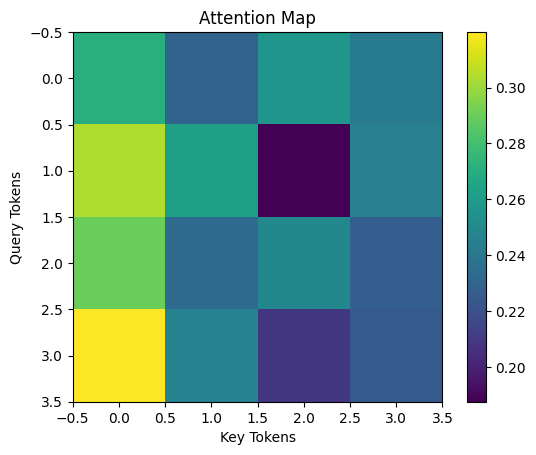

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(weights[0].detach().numpy(), cmap='viridis')
plt.colorbar()
plt.title("Attention Map")
plt.xlabel("Key Tokens")
plt.ylabel("Query Tokens")
plt.show()


5. Attention Head Importance Analysis (Ablation)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math

torch.manual_seed(0)
class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads

        self.Wq = nn.Linear(embed_dim, embed_dim)
        self.Wk = nn.Linear(embed_dim, embed_dim)
        self.Wv = nn.Linear(embed_dim, embed_dim)
        self.fc = nn.Linear(embed_dim, embed_dim)

    def split_heads(self, x):
        B, S, E = x.shape
        x = x.view(B, S, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def combine_heads(self, x):
        B, H, S, D = x.shape
        x = x.transpose(1, 2).contiguous()
        return x.view(B, S, H * D)

    def forward(self, x):
        Q = self.split_heads(self.Wq(x))
        K = self.split_heads(self.Wk(x))
        V = self.split_heads(self.Wv(x))

        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.head_dim)
        weights = F.softmax(scores, dim=-1)
        attn = torch.matmul(weights, V)

        combined = self.combine_heads(attn)
        return self.fc(combined)

    #Remove One Head
    def ablate_head(self, head_index):
        start = head_index * self.head_dim
        end = start + self.head_dim
        self.Wq.weight.data[:, start:end] = 0
        self.Wk.weight.data[:, start:end] = 0
        self.Wv.weight.data[:, start:end] = 0
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.mha = MultiHeadAttention(16, 4)
        self.fc = nn.Linear(16, 2)

    def forward(self, x):
        x = self.mha(x)
        x = x.mean(dim=1)   # average pooling
        return self.fc(x)
def get_data(n=100):
    X = torch.rand(n, 5, 16)
    y = (X.mean(dim=(1,2)) > 0.5).long()
    return X, y

X, y = get_data()
model = Model()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

for epoch in range(50):
    optimizer.zero_grad()
    preds = model(X)
    loss = F.cross_entropy(preds, y)
    loss.backward()
    optimizer.step()
def accuracy(m):
    with torch.no_grad():
        preds = m(X).argmax(dim=1)
        return (preds == y).float().mean().item()

base_acc = accuracy(model)
print("Base Accuracy:", round(base_acc, 3))
for h in range(4):
    test_model = Model()
    test_model.load_state_dict(model.state_dict())

    test_model.mha.ablate_head(h)
    acc = accuracy(test_model)

    print(f"After Removing Head {h} → Accuracy: {round(acc,3)}")

Base Accuracy: 1.0
After Removing Head 0 → Accuracy: 0.52
After Removing Head 1 → Accuracy: 0.66
After Removing Head 2 → Accuracy: 0.49
After Removing Head 3 → Accuracy: 0.9


6. Transformer Encoder Block

In [ ]:
class TransformerEncoder(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.ffn = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 4),
            nn.ReLU(),
            nn.Linear(embed_dim * 4, embed_dim)
        )
        self.norm2 = nn.LayerNorm(embed_dim)

    def forward(self, x):
        x = self.norm1(x + self.attn(x))
        x = self.norm2(x + self.ffn(x))
        return x
encoder = TransformerEncoder(embed_dim=8, num_heads=2)
x = torch.rand(1, 4, 8)
output = encoder(x)

print("Encoder Output:")
print(output)


Encoder Output:
tensor([[[-0.4323,  1.1571, -0.3006, -0.5546,  2.0334, -0.2290, -0.3430,
          -1.3310],
         [ 0.1320, -1.3523, -0.2939,  0.2126, -0.2251,  2.3366, -0.7083,
          -0.1016],
         [ 1.8728, -1.4797,  0.3299, -0.9929,  0.4520,  0.3752,  0.3162,
          -0.8737],
         [-0.4422, -0.5397,  1.7913, -1.7684, -0.2275, -0.1214,  1.0111,
           0.2968]]], grad_fn=<NativeLayerNormBackward0>)


7. Positional Encoding Experiment

In [ ]:
import math

def positional_encoding(seq_len, embed_dim):
    pe = torch.zeros(seq_len, embed_dim)
    for pos in range(seq_len):
        for i in range(0, embed_dim, 2):
            pe[pos, i] = math.sin(pos / (10000 ** (i / embed_dim)))
            pe[pos, i+1] = math.cos(pos / (10000 ** (i / embed_dim)))
    return pe

print(positional_encoding(4, 8))


tensor([[ 0.0000e+00,  1.0000e+00,  0.0000e+00,  1.0000e+00,  0.0000e+00,
          1.0000e+00,  0.0000e+00,  1.0000e+00],
        [ 8.4147e-01,  5.4030e-01,  9.9833e-02,  9.9500e-01,  9.9998e-03,
          9.9995e-01,  1.0000e-03,  1.0000e+00],
        [ 9.0930e-01, -4.1615e-01,  1.9867e-01,  9.8007e-01,  1.9999e-02,
          9.9980e-01,  2.0000e-03,  1.0000e+00],
        [ 1.4112e-01, -9.8999e-01,  2.9552e-01,  9.5534e-01,  2.9996e-02,
          9.9955e-01,  3.0000e-03,  1.0000e+00]])
